In this assignment, you will transition from static word embeddings to sequential modeling. You will reuse the IMDB dataset from Week 3 to build, train, and evaluate RNN and LSTM architectures.

Assignment Objectives:    
	1.	Sequential Learning: Implement padding and truncation to handle variable-length text

	2.  Architectural Construction: Manually 'wire' RNN and LSTM layers using Keras

	3.	The Vanishing Gradient: Conduct a controlled experiment varying sequence lengths to observe how RNNs 'forget' long-range context

	4. Performance Auditing: Compare sequential models against your Week 3 baseline using Accuracy, Precision, Recall, and F1-score.

Week 3 Reuse:
	•	Reuse tokenizer/vocab
	•	Reuse embeddings source (Word2Vec/GloVe)
	•	Reuse train/val/test splits

## Part 1: Preprocessing & GloVe Integration (10 Points)


Step 1: Load data and tokenize.

In [1]:
from tensorflow.keras.datasets import imdb

# Load IMDB dataset with full vocabulary
(x_train, y_train), (x_test, y_test) = imdb.load_data()

# Combine training and testing datasets to select 10,000 reviews
X_train = x_train.tolist()
y_train = y_train.tolist()

# Display dataset size
print("Total Reviews Selected:", len(X_train))

# Decode IMDB reviews (word index mapping provided by Keras)
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])  # Offset for special tokens

# Decode and display a sample review
print("\nSample Decoded Review:", decode_review(X_train[0]))
print("Sample Label (0=Negative, 1=Positive):", y_train[0])

# Pad sequences to ensure uniform length
# max_len = 200  # Maximum sequence length for padding
# x_data_padded = pad_sequences(x_data, maxlen=max_len, padding='post')

#print("\nPadded Review Shape:", x_data_padded.shape)

2026-02-08 17:07:01.644387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 17:07:02.030596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 17:07:03.256159: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.p

Total Reviews Selected: 25000

Sample Decoded Review: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the w

In [2]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove handles
    text = re.sub(r'\B@\S+','',text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Rmeove emojis
    emoji_pattern = re.compile(
    "["
    "\\U0001F600-\\U0001F64F"  # emoticons
    "\\U0001F300-\\U0001F5FF"  # symbols & pictographs
    "\\U0001F680-\\U0001F6FF"  # transport & map symbols
    "\\U0001F1E0-\\U0001F1FF"  # flags (iOS)
    "\\U00002702-\\U000027B0"
    "\\U000024C2-\\U0001F251"
    "]+", flags=re.UNICODE
)
    text = emoji_pattern.sub(r'', text)

    return text

In [3]:
preprocessed_x_data = []
for review in X_train:
    preprocessed_x_data.append(clean_text(decode_review(review)))

preprocessed_x_data[0][:100]

' this film was just brilliant casting location scenery story direction everyones really suited the p'

In [4]:
## Student Code Required ##
# Instruction: Initialize the Tokenizer and pad your sequences.
# You must also map your pre-trained vectors from Week 3
# into a weight matrix for the Keras Embedding layer.


# ==================== Part 1: Preprocessing ====================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Define vocabulary and sequence constraints
VOCAB_SIZE = 60000
MAX_LEN = 250 

# Tokenize data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(preprocessed_x_data)
word_index = tokenizer.word_index

# Add 0 to the word index
word_index['<PAD>'] = 0

# Reuse the Week 3 tokenizer (do not fit a new tokenizer)
# Implement padding logic
def prepare_sequences(data, length):
    sequences = tokenizer.texts_to_sequences(data)
    return pad_sequences(sequences, maxlen=length, padding='pre')

# Generate the sequences
padded_sequences = prepare_sequences(preprocessed_x_data, MAX_LEN)

# Map Week 3 vectors to the new vocabulary matrix
# Assumption: From Week 3, you already have access to pre-trained word embeddings
# in one of the following forms:
	##	embeddings_index[word] → np.array (e.g., GloVe dictionary), or
	##	word2vec_model.wv[word] → np.array (gensim Word2Vec).
  ## Use whichever representation you created in Week 3.

# Get the embeddings index, used in module 3
glove_embeddings_index = {}
with open("data/glove.6B.100d.txt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        glove_embeddings_index[word] = {i:coefs}

#Add the <PAD> token
glove_embeddings_index['<PAD>'] = {len(glove_embeddings_index):np.zeros(100, dtype=np.float32)}

# embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
# ... (Student implementation of mapping logic)

def create_embedding_matrix(tokenizer, glove_embeddings_index:dict, vocab_size = VOCAB_SIZE, embedding_dim=100):
    vocab_size = VOCAB_SIZE+1
    # This ensures that padding (index 0) and OOV words (not found or outside vocab size) are zero-vectors
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Iterate through the tokenizer's vocabulary
    hits = 0
    misses = 0
    oov = 0
    tokens = 0
    
    for word, i in tokenizer.word_index.items():
        # Try to find the word in the pre-trained model
        try:
            if tokens < vocab_size:
                embedding_vector = list(glove_embeddings_index[word].values())[0]
                embedding_matrix[tokens] = embedding_vector
                hits += 1
                # Count the number of tokens added to the matrix.
                tokens += 1
            else:
                oov += 1
        except KeyError:
            # If word is not in pre-trained model, it stays as zeros (or you can randomize it)
            misses += 1
        
    print(f"Converted {hits} words ({misses} misses, {oov} OOV)")
    return embedding_matrix

embedding_matrix = create_embedding_matrix(tokenizer, glove_embeddings_index)
print(embedding_matrix.shape)

Converted 60001 words (17658 misses, 917 OOV)
(60001, 100)


Exercise:
1.   Compare the raw text to its padded sequence. For an RNN, why is 'pre-padding' (adding zeros at the beginning) generally preferred over 'post-padding' (adding zeros at the end)?
2.   How does the choice of MAX_LEN impact the computational cost of the training phase?


In [5]:
raw_data = decode_review(x_train.tolist()[0])
print(f'RAW DATA:\n{raw_data[:250]}\n')
print(f'PREPROCESSED DATA:\n{preprocessed_x_data[0][:250]}\n')
print(f'PADDED DATA: {padded_sequences[0]}')

RAW DATA:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came fro

PREPROCESSED DATA:
 this film was just brilliant casting location scenery story direction everyones really suited the part they played and you could just imagine being there robert redfords is an amazing actor and now the same being director normans father came from th

PADDED DATA: [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0    11    19    13
    41   524   960  1597  1369    61   452  4211    63  3902     1   169
    34   251     2    22    98    41   826   108    47   661 21393     6
    33   472   281     2   147     1   168   108   163 20153   328   378
    37     1   1

#### Answers:

1. Pre-padding is generally preferred with RNN models because they lose contextual understanding over the course of the sequence. With pre-padding, the pad tokens are present in the beginning of the sequence, which is beneificial for context loss over the sequence length. For post padding, the lost context would be comprised of exclusively tokens, negatively impacting the model performance due to the degredation of semantic understanding.
2. Due to the reccurent nature of this model architecture, MAX_LEN exponentially increases the training time because each output of the sequence is fed back into the input of the model.  

## Part 2: RNN Implementation & Loss Curves (25 Points)

In [6]:
# Define vocabulary and sequence constraints
VOCAB_SIZE = 60000
MAX_LEN = 250 

# Format data for training.
X_train, y_train = padded_sequences, np.array(y_train).astype(np.float32)

# Format the validation data
X_val = x_test[:5000].tolist()

# Preprocess the data
preprocessed_x_val = []
for review in X_val:
    preprocessed_x_val.append(clean_text(decode_review(review)))
X_val = prepare_sequences(preprocessed_x_val, MAX_LEN)

# Convert y data to np array with the correct dtype
y_val = np.array(y_test[:5000].tolist()).astype(np.float32)

In [7]:
## Student Code Required ##
# Instruction: Implement a SimpleRNN.
# You are responsible for selecting the hidden units
#  and dropout rates to prevent overfitting.

# ==================== Part 2: RNN Implementation ====================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

# Define the sequential architecture
model_rnn = Sequential([
    Embedding(VOCAB_SIZE+1, 
              output_dim=embedding_matrix.shape[1], 
              weights=[embedding_matrix], 
              input_length = MAX_LEN,
              trainable=False),
    SimpleRNN(64 ,activation='tanh'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# if labels are multi-class, replace sigmoid/binary_crossentropy with
# softmax/sparse_categorical_crossentropy

# Train the model and store the 'history' object for plotting
history_rnn = model_rnn.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val))
## use week 3 validation split

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1770588434.500496     670 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/15


2026-02-08 17:07:16.078297: I external/local_xla/xla/service/service.cc:163] XLA service 0x721d0800ab10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-08 17:07:16.078321: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
2026-02-08 17:07:16.102703: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-08 17:07:16.225382: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-08 17:07:16.279591: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-08 17:07:16.27963

  5/782 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.4300 - loss: 0.8700

I0000 00:00:1770588437.494495     918 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.5207 - loss: 0.7158 - val_accuracy: 0.5324 - val_loss: 0.6967
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.5530 - loss: 0.6870 - val_accuracy: 0.5698 - val_loss: 0.6783
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.5719 - loss: 0.6766 - val_accuracy: 0.5564 - val_loss: 0.6801
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.5736 - loss: 0.6751 - val_accuracy: 0.5482 - val_loss: 0.6862
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5972 - loss: 0.6640 - val_accuracy: 0.5680 - val_loss: 0.6792
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6087 - loss: 0.6556 - val_accuracy: 0.5962 - val_loss: 0.6673
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6224 - loss: 0.6438 - val_accuracy: 0.5858 - val_loss: 0.6724
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6371 - loss: 0.6363 - val_accurac

In [8]:
import matplotlib.pyplot as plt

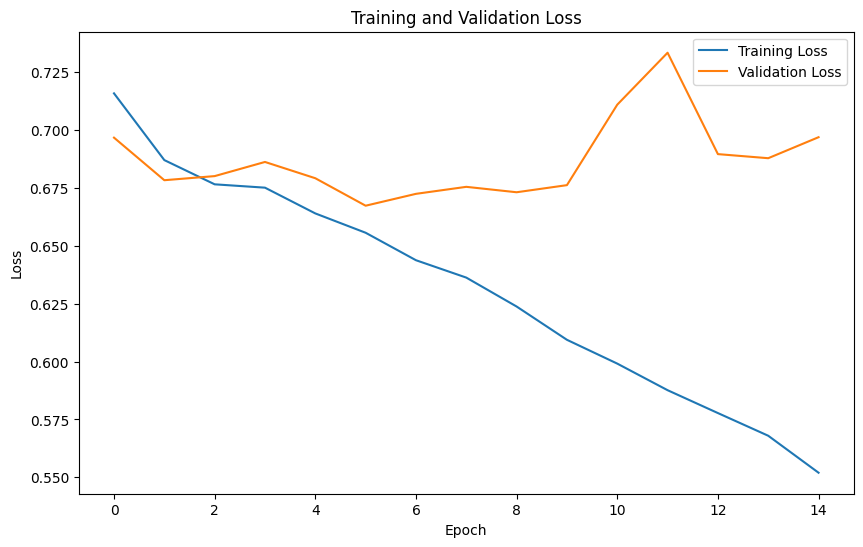

In [9]:
# Get training and validation loss values
train_loss = model_rnn.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = model_rnn.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

## Part 3: LSTM Implementation & Comparison(25 Points)

In [10]:
## Student Code Required ##
# Instruction: Using the same pipeline, implement an LSTM.
# Observe how the gating mechanism affects training stability.

# ==================== Part 3: LSTM Implementation ====================
from tensorflow.keras.layers import LSTM

# Replicate the architecture using an LSTM layer
model_lstm = Sequential([
    Embedding(VOCAB_SIZE+1, 100, weights=[embedding_matrix], trainable=False),
    LSTM(128), # Implement LSTM layer
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.5490 - loss: 0.6864 - val_accuracy: 0.5994 - val_loss: 0.6682
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6340 - loss: 0.6411 - val_accuracy: 0.6676 - val_loss: 0.6236
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6904 - loss: 0.5886 - val_accuracy: 0.7174 - val_loss: 0.5520
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7440 - loss: 0.5198 - val_accuracy: 0.7504 - val_loss: 0.5174
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7854 - loss: 0.4601 - val_accuracy: 0.7634 - val_loss: 0.4835
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8200 - loss: 0.4027 - val_accuracy: 0.7904 - val_loss: 0.4627
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8445 - loss: 0.3585 - val_accuracy: 0.8018 - val_loss: 0.4272
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8680 - loss: 0.3108 - 

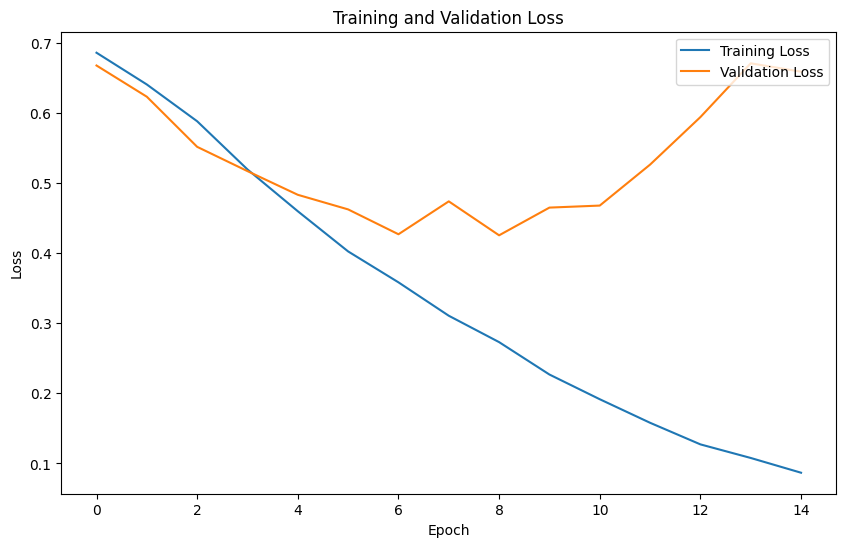

In [11]:
# Get training and validation loss values
train_loss = model_lstm.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = model_lstm.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

Exercise:
1.   Analyze your accuracy and loss curves for both models. Did you observe 'exploding gradients' or a plateau in the SimpleRNN?
2.   Explain how the Forget Gate in the LSTM specifically addresses the issues you saw in the standard RNN



#### Answers

1. The SimpleRNN exhibited plateauing validation loss and accuracy that is marginally better than random guessing, about 59%. Ultimately, the model seemed to be inadequate for this task.
2. The Forget Gate can selectively diminish weights associated with out of context embedding vectors. This solves the common issues with RNNs by increasing the context window in a given sequence or recontextualizing words based on changes in the subject or verb of the sentence.

## Part 4: Hyperparameter Tuning & Vanishing Gradient(30 Points)


### Stop & Think: The Vanishing Gradient Hypothesis

**Before running the code below, verify your understanding of the theory.**

Recall from the lecture that SimpleRNNs have a "short-term memory" problem. Mathematically, this happens because the gradients (the signals used to update weights) become smaller and smaller as they travel back through time.

**Hypothesis Task:**
Predict what will happen when we force the SimpleRNN to remember a sequence of 200 words instead of just 100.

1.  **Stability**: Will the model continue to learn, or will the accuracy "flatline" early?
2.  **Bias** :If the model forgets the beginning of the review (where the context often is), what is its safest bet? Will it guess randomly, or will it just predict "Positive" for everything because most reviews are positive?


*Write your hypothesis here before proceeding.*

**Hypothesis:**

1. The model will likely flatline early with the larger sequence as a result of vanishing gradients. This is a result of minimal signal from which the model can learn.
2. My assumption is that the model will degrade to random guessing. It seems unlikely that the model will continuously predict positive because there will be no context to discern the cause of the positive label. Additionally, text data is sparse, so it is possible the validation data does not contain the few key tokens that the model learns to make predictions.

In [12]:
## Student Code Required ##
# Instruction: Rerun your models using sequence lengths of 100 vs. 200
# Document the impact in a comparison table

# ==================== Part 4: Tuning Experiment ====================
# Student Task: Compare accuracy across varying sequence lengths
# Length 100 vs 200
# Hidden Units 64 vs 128
# Dropout 0.2

# Create a summary table (Pandas DataFrame) to document the results
  # Example: model_type, seq_len, hidden_units, val_acc, val_loss, notes

In [13]:
results = {
        'Model':[],
        'Sequence Length':[],
        'Hidden Units':[],
        'Val Accuracy':[],
        'Val Loss':[],
        'Novel Accuracy':[],
        'Recall':[],
        'Precision':[],
        'F1-Score':[],
        'Notes':[]
           }

labels = ["Positive", "Negative"]

In [14]:
novel_x = x_test[20000:]
novel_y = np.array(y_test[20000:]).astype(np.float32)

# Transform the x data with preprocessing, tokenization, and padding
preprocessed_novel_x = []
for review in novel_x:
    preprocessed_novel_x.append(clean_text(decode_review(review)))

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt

class ModelEvaluator():
    def __init__(self, fit_model):
        self.model = fit_model
    
    def eval_model(self, X_test, y_test, labels, plot=True):
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.model.predict(X_test)
            
        for i in range(len(self.predictions)):
            if self.predictions[i]>=0.500:
                self.predictions[i]=1
            else:
                self.predictions[i]=0

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, true_val in enumerate(self.novel_y):
            if self.predictions[i] == 1 and true_val == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.predictions[i] == 1 and true_val == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.predictions[i] == 0 and true_val == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.predictions[i] == 0 and true_val == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        if plot:
            self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):

        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

In [ ]:
# Define vocabulary and sequence constraints
MAX_LEN = 200

In [17]:
def tokenize_and_embed(preprocessed_x_data, max_len):
    # Tokenize data
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(preprocessed_x_data)
    word_index = tokenizer.word_index

    # Add 0 to the word index
    word_index['<PAD>'] = 0

    # Generate the sequences
    X_train = prepare_sequences(preprocessed_x_data, max_len)

    # Map Week 3 vectors to the new vocabulary matrix
    # Assumption: From Week 3, you already have access to pre-trained word embeddings
    # in one of the following forms:
        ##	embeddings_index[word] → np.array (e.g., GloVe dictionary), or
        ##	word2vec_model.wv[word] → np.array (gensim Word2Vec).
    ## Use whichever representation you created in Week 3.

    # Get the embeddings index, used in module 3
    glove_embeddings_index = {}
    with open("data/glove.6B.100d.txt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            glove_embeddings_index[word] = {i:coefs}

    #Add the <PAD> token
    glove_embeddings_index['<PAD>'] = {len(glove_embeddings_index):np.zeros(100, dtype=np.float32)}

    # embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
    # ... (Student implementation of mapping logic)

    embedding_matrix = create_embedding_matrix(tokenizer, glove_embeddings_index)

    return X_train, embedding_matrix

### RNN (MAX_LEN = 200, Units = 128)

In [ ]:
# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Define the sequential architecture
model_rnn_200_128 = Sequential([
    Embedding(VOCAB_SIZE+1, 
              output_dim=embedding_matrix.shape[1], 
              weights=[embedding_matrix], 
              input_length = MAX_LEN,
              trainable=False),
    SimpleRNN(128 ,activation='tanh'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn_200_128.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# if labels are multi-class, replace sigmoid/binary_crossentropy with
# softmax/sparse_categorical_crossentropy

# Train the model and store the 'history' object for plotting
model_rnn_200_128.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val))

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_rnn_200_128_eval = ModelEvaluator(model_rnn_200_128)
model_rnn_200_128_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('RNN')
results['Sequence Length'].append(200)
results['Hidden Units'].append(128)
results['Val Accuracy'].append(model_rnn_200_128.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_rnn_200_128.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_rnn_200_128_eval.accuracy)
results['Recall'].append(model_rnn_200_128_eval.recall)
results['Precision'].append(model_rnn_200_128_eval.precision)
results['F1-Score'].append(model_rnn_200_128_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)
Epoch 1/15


2026-02-08 17:16:04.166766: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-08 17:16:04.166809: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-08 17:16:04.166816: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-08 17:16:04.166822: I external/l

781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5093 - loss: 0.7274

2026-02-08 17:16:23.085795: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 12 bytes spill stores, 12 bytes spill loads



782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5150 - loss: 0.7163 - val_accuracy: 0.5462 - val_loss: 0.6871
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5508 - loss: 0.6859 - val_accuracy: 0.5492 - val_loss: 0.6832
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5764 - loss: 0.6753 - val_accuracy: 0.5528 - val_loss: 0.6822
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5892 - loss: 0.6683 - val_accuracy: 0.5648 - val_loss: 0.6824
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6097 - loss: 0.6569 - val_accuracy: 0.5730 - val_loss: 0.6768
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6266 - loss: 0.6459 - val_accuracy: 0.5692 - val_loss: 0.6776
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.6308 - loss: 0.6399 - val_accuracy: 0.5808 - val_loss: 0.6754
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.6522 - loss: 0.6203 - val_accurac

### RNN (MAX_LEN = 200, Units = 64)

In [19]:
# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Define the sequential architecture
model_rnn_200_64 = Sequential([
    Embedding(VOCAB_SIZE+1, 
              output_dim=embedding_matrix.shape[1], 
              weights=[embedding_matrix], 
              input_length = MAX_LEN,
              trainable=False),
    SimpleRNN(64 ,activation='tanh'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn_200_64.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# if labels are multi-class, replace sigmoid/binary_crossentropy with
# softmax/sparse_categorical_crossentropy

# Train the model and store the 'history' object for plotting
model_rnn_200_64.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_rnn_200_64_eval = ModelEvaluator(model_rnn_200_64)
model_rnn_200_64_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('RNN')
results['Sequence Length'].append(200)
results['Hidden Units'].append(64)
results['Val Accuracy'].append(model_rnn_200_64.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_rnn_200_64.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_rnn_200_64_eval.accuracy)
results['Recall'].append(model_rnn_200_64_eval.recall)
results['Precision'].append(model_rnn_200_64_eval.precision)
results['F1-Score'].append(model_rnn_200_64_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)


/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Number of Negative Predictions: 2457
Number of Positive Predictions: 2543
Percent Negative Predictions: 49.14
Percent Positive Predictions: 50.86000000000001

Accuracy: 60.36%

Recall: 0.5930278104191148

Precision: 0.6161986161986162

F1-Score: 0.60


### RNN (MAX_LEN = 100, Units = 128)

In [20]:
# Define vocabulary and sequence constraints
MAX_LEN = 100

In [21]:
# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Define the sequential architecture
model_rnn_100_128 = Sequential([
    Embedding(VOCAB_SIZE+1, 
              output_dim=embedding_matrix.shape[1], 
              weights=[embedding_matrix], 
              input_length = MAX_LEN,
              trainable=False),
    SimpleRNN(128 ,activation='tanh'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn_100_128.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# if labels are multi-class, replace sigmoid/binary_crossentropy with
# softmax/sparse_categorical_crossentropy

# Train the model and store the 'history' object for plotting
model_rnn_100_128.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_rnn_100_128_eval = ModelEvaluator(model_rnn_100_128)
model_rnn_100_128_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('RNN')
results['Sequence Length'].append(100)
results['Hidden Units'].append(128)
results['Val Accuracy'].append(model_rnn_100_128.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_rnn_100_128.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_rnn_100_128_eval.accuracy)
results['Recall'].append(model_rnn_100_128_eval.recall)
results['Precision'].append(model_rnn_100_128_eval.precision)
results['F1-Score'].append(model_rnn_100_128_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)


/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Number of Negative Predictions: 2859
Number of Positive Predictions: 2141
Percent Negative Predictions: 57.18
Percent Positive Predictions: 42.82

Accuracy: 59.72%

Recall: 0.6654915785350568

Precision: 0.5942637285764253

F1-Score: 0.63


### RNN (MAX_LEN = 100, Units = 64)

In [22]:
# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Define the sequential architecture
model_rnn_100_64 = Sequential([
    Embedding(VOCAB_SIZE+1, 
              output_dim=embedding_matrix.shape[1], 
              weights=[embedding_matrix], 
              input_length = MAX_LEN,
              trainable=False),
    SimpleRNN(64 ,activation='tanh'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_rnn_100_64.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# if labels are multi-class, replace sigmoid/binary_crossentropy with
# softmax/sparse_categorical_crossentropy

# Train the model and store the 'history' object for plotting
model_rnn_100_64.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_rnn_100_64_eval = ModelEvaluator(model_rnn_100_64)
model_rnn_100_64_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('RNN')
results['Sequence Length'].append(100)
results['Hidden Units'].append(64)
results['Val Accuracy'].append(model_rnn_100_64.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_rnn_100_64.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_rnn_100_64_eval.accuracy)
results['Recall'].append(model_rnn_100_64_eval.recall)
results['Precision'].append(model_rnn_100_64_eval.precision)
results['F1-Score'].append(model_rnn_100_64_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)


/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Number of Negative Predictions: 2541
Number of Positive Predictions: 2459
Percent Negative Predictions: 50.82
Percent Positive Predictions: 49.18

Accuracy: 63.68%

Recall: 0.6419898159028594

Precision: 0.645021645021645

F1-Score: 0.64


### LSTM (MAX_LEN = 200, Units = 128)

In [23]:
MAX_LEN = 200

In [24]:
# Set units
units = 128

# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Replicate the architecture using an LSTM layer
model_lstm_200_128 = Sequential([
    Embedding(VOCAB_SIZE+1, 100, weights=[embedding_matrix], trainable=False),
    LSTM(units), # Implement LSTM layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm_200_128.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm_200_128.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_lstm_200_128_eval = ModelEvaluator(model_lstm_200_128)
model_lstm_200_128_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('LSTM')
results['Sequence Length'].append(200)
results['Hidden Units'].append(units)
results['Val Accuracy'].append(model_lstm_200_128.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_lstm_200_128.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_lstm_200_128_eval.accuracy)
results['Recall'].append(model_lstm_200_128_eval.recall)
results['Precision'].append(model_lstm_200_128_eval.precision)
results['F1-Score'].append(model_lstm_200_128_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Number of Negative Predictions: 2651
Number of Positive Predictions: 2349
Percent Negative Predictions: 53.02
Percent Positive Predictions: 46.98

Accuracy: 80.40%

Recall: 0.827262044653349

Precision: 0.7966804979253111

F1-Score: 0.81


### LSTM (MAX_LEN = 200, Units = 64)

In [25]:
# Set units
units = 64

# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Replicate the architecture using an LSTM layer
model_lstm_200_64 = Sequential([
    Embedding(VOCAB_SIZE+1, 100, weights=[embedding_matrix], trainable=False),
    LSTM(units), # Implement LSTM layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm_200_64.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm_200_64.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_lstm_200_64_eval = ModelEvaluator(model_lstm_200_64)
model_lstm_200_64_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('LSTM')
results['Sequence Length'].append(200)
results['Hidden Units'].append(units)
results['Val Accuracy'].append(model_lstm_200_64.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_lstm_200_64.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_lstm_200_64_eval.accuracy)
results['Recall'].append(model_lstm_200_64_eval.recall)
results['Precision'].append(model_lstm_200_64_eval.precision)
results['F1-Score'].append(model_lstm_200_64_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Number of Negative Predictions: 2468
Number of Positive Predictions: 2532
Percent Negative Predictions: 49.36
Percent Positive Predictions: 50.63999999999999

Accuracy: 80.14%

Recall: 0.7888758323540932

Precision: 0.8160453808752026

F1-Score: 0.80


### LSTM (MAX_LEN = 100, Units = 128)

In [26]:
MAX_LEN = 100

In [27]:
# Set units
units = 128

# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Replicate the architecture using an LSTM layer
model_lstm_100_128 = Sequential([
    Embedding(VOCAB_SIZE+1, 100, weights=[embedding_matrix], trainable=False),
    LSTM(units), # Implement LSTM layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm_100_128.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm_100_128.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_lstm_100_128_eval= ModelEvaluator(model_lstm_100_128)
model_lstm_100_128_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('LSTM')
results['Sequence Length'].append(100)
results['Hidden Units'].append(units)
results['Val Accuracy'].append(model_lstm_100_128.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_lstm_100_128.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_lstm_100_128_eval.accuracy)
results['Recall'].append(model_lstm_100_128_eval.recall)
results['Precision'].append(model_lstm_100_128_eval.precision)
results['F1-Score'].append(model_lstm_100_128_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Number of Negative Predictions: 2471
Number of Positive Predictions: 2529
Percent Negative Predictions: 49.419999999999995
Percent Positive Predictions: 50.580000000000005

Accuracy: 76.52%

Recall: 0.754014884449667

Precision: 0.7790368271954674

F1-Score: 0.77


### LSTM (MAX_LEN = 100, Units = 64)

In [28]:
# Set units
units = 64

# Get the x_data and embedding matrix based on the new max_len
X_train, embedding_matrix = tokenize_and_embed(preprocessed_x_data, MAX_LEN)

# Replicate the architecture using an LSTM layer
model_lstm_100_64 = Sequential([
    Embedding(VOCAB_SIZE+1, 100, weights=[embedding_matrix], trainable=False),
    LSTM(units), # Implement LSTM layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm_100_64.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm_100_64.fit(X_train, y_train, epochs=15, validation_data= (X_val, y_val), verbose=False)

# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, MAX_LEN)

model_lstm_100_64_eval = ModelEvaluator(model_lstm_100_64)
model_lstm_100_64_eval.eval_model(X_novel, novel_y, labels=labels, plot=False)

results['Model'].append('LSTM')
results['Sequence Length'].append(100)
results['Hidden Units'].append(units)
results['Val Accuracy'].append(model_lstm_100_64.history.history['val_accuracy'][-1])
results['Val Loss'].append(model_lstm_100_64.history.history['val_loss'][-1])
results['Novel Accuracy'].append(model_lstm_100_64_eval.accuracy)
results['Recall'].append(model_lstm_100_64_eval.recall)
results['Precision'].append(model_lstm_100_64_eval.precision)
results['F1-Score'].append(model_lstm_100_64_eval.f1_score)

Converted 60001 words (17658 misses, 917 OOV)
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Number of Negative Predictions: 2476
Number of Positive Predictions: 2524
Percent Negative Predictions: 49.519999999999996
Percent Positive Predictions: 50.480000000000004

Accuracy: 77.38%

Recall: 0.7634155895025461

Precision: 0.787156704361874

F1-Score: 0.78


In [29]:
import pandas as pd

In [30]:
results['Notes'] = ['N/A']*len(results['Model'])

In [31]:
results_df = pd.DataFrame(results)
results_df

,Model,Sequence Length,Hidden Units,Val Accuracy,Val Loss,Novel Accuracy,Recall,Precision,F1-Score,Notes
0,RNN,200,128,0.5966,0.750825,60.88%,0.710928,0.598417,0.65,N/A
1,RNN,200,64,0.5996,0.698519,60.36%,0.593028,0.616199,0.60,N/A
2,RNN,100,128,0.5836,0.760401,59.72%,0.665492,0.594264,0.63,N/A
3,RNN,100,64,0.6190,0.680875,63.68%,0.641990,0.645022,0.64,N/A
4,LSTM,200,128,0.7968,0.954727,80.40%,0.827262,0.796680,0.81,N/A
5,LSTM,200,64,0.7944,0.560590,80.14%,0.788876,0.816045,0.80,N/A
6,LSTM,100,128,0.7886,0.985786,76.52%,0.754015,0.779037,0.77,N/A
7,LSTM,100,64,0.7926,0.600871,77.38%,0.763416,0.787157,0.78,N/A


**Exercise:**

Diagnosing the "Memory Loss": Don't just look at the accuracy score—look at *how* the model failed.

**Task:**
Generate a **Confusion Matrix** for your `SimpleRNN` (Sequence Length = 200) on the validation set.

```python
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions for the long-sequence RNN
# y_pred_rnn = ... (your prediction logic here)

# cm = confusion_matrix(y_val, y_pred_rnn)
# sns.heatmap(cm, annot=True, fmt='d')

```

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Number of Negative Predictions: 3033
Number of Positive Predictions: 1967
Percent Negative Predictions: 60.660000000000004
Percent Positive Predictions: 39.34

Accuracy: 60.88%

Recall: 0.7109283196239718

Precision: 0.5984174085064293

F1-Score: 0.65


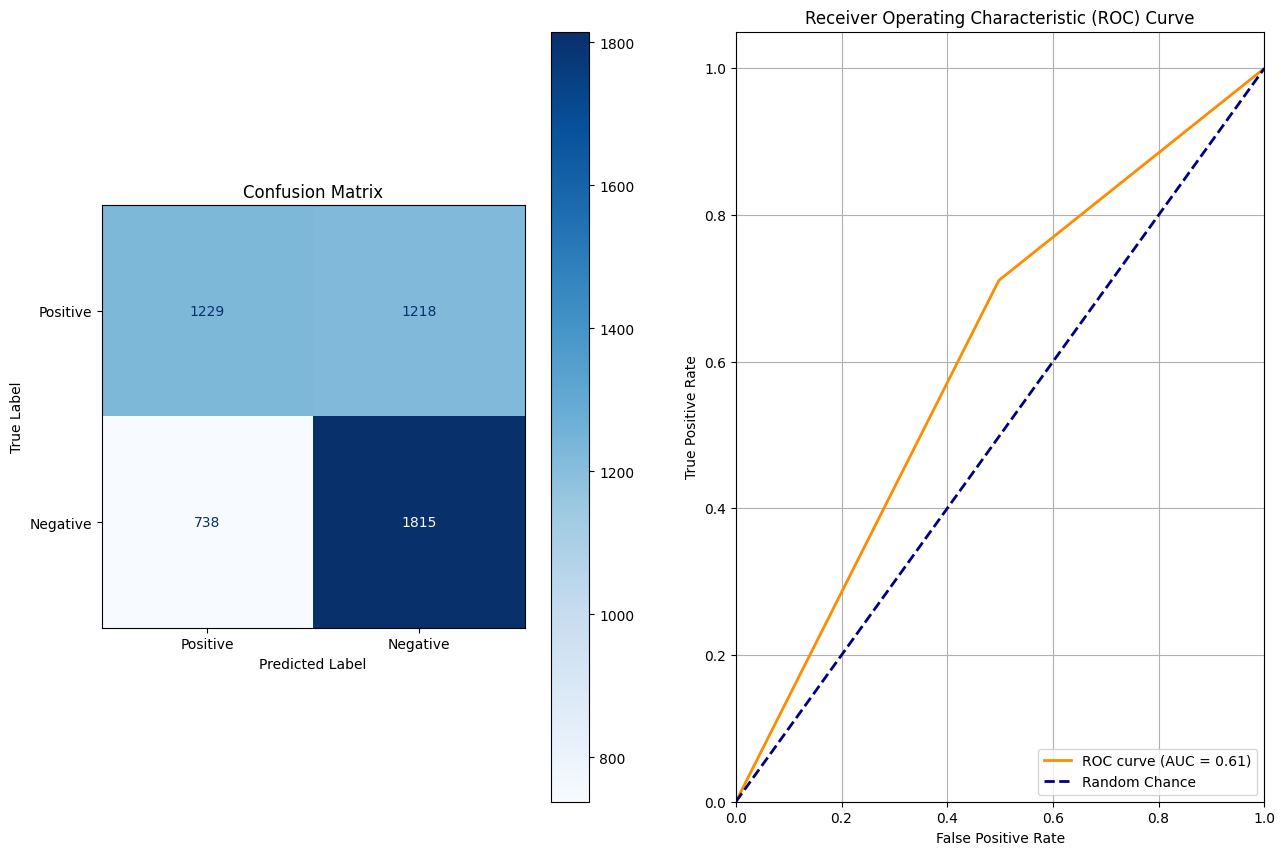

In [32]:
# Ensure X_val has the same sequence length 
X_novel = prepare_sequences(preprocessed_novel_x, 200)

model_rnn_200_128_eval.eval_model(X_novel, novel_y, labels=labels)

**Questions:**

* The "Majority Vote" Trap: Look at your confusion matrix. Did the SimpleRNN actually "learn" the difference between positive and negative, or did it just predict the most frequent class for every review?

*The model did not learn the difference between positive and negative as it reached a 60% accuracy rating with a 60-40 split between positive and negative predictions, indicating there model was beginning to learn only negative class predictions. The model appeared to plateau in it's learning around this point, however.*

* The LSTM Difference: The LSTM introduces a "Cell State". Explain how this "highway" for information allows the LSTM to keep the gradient signal alive for 200 steps, whereas the SimpleRNN's standard hidden state lets it fade away.

*The Cell State only utilizes linear operations and 'pulls out' the important information from each step in the cell, eliminating the reduction caused by recursive multiplication of the hidden state in RNNs. The entire model is comprised of 32 bit floating point numbers between 0 and 1, which will continue to become smaller and smaller for each subsequent multiplication operation in the recurrent hidden state, diluting the meaning of the tokens in the sequence. LSTM targets this specifically with the cell state.*


## Part 5: Model Evaluation (10 Points)

In [33]:
novel_x = x_test[20000:]
novel_y = np.array(y_test[20000:]).astype(np.float32)

# Transform the x data with preprocessing, tokenization, and padding
preprocessed_novel_x = []
for review in novel_x:
    preprocessed_novel_x.append(clean_text(decode_review(review)))

#NOTE: The commented out lines, below, are very incorrect and you should never do this again.
#tokenizer.fit_on_texts(preprocessed_novel_x)
#novel_word_index = tokenizer.word_index
novel_padded_sequences = prepare_sequences(preprocessed_novel_x, MAX_LEN)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Number of Negative Predictions: 1844
Number of Positive Predictions: 3156
Percent Negative Predictions: 36.88
Percent Positive Predictions: 63.12

Accuracy: 63.10%

Recall: 0.49980415197806505

Precision: 0.6919739696312365

F1-Score: 0.58


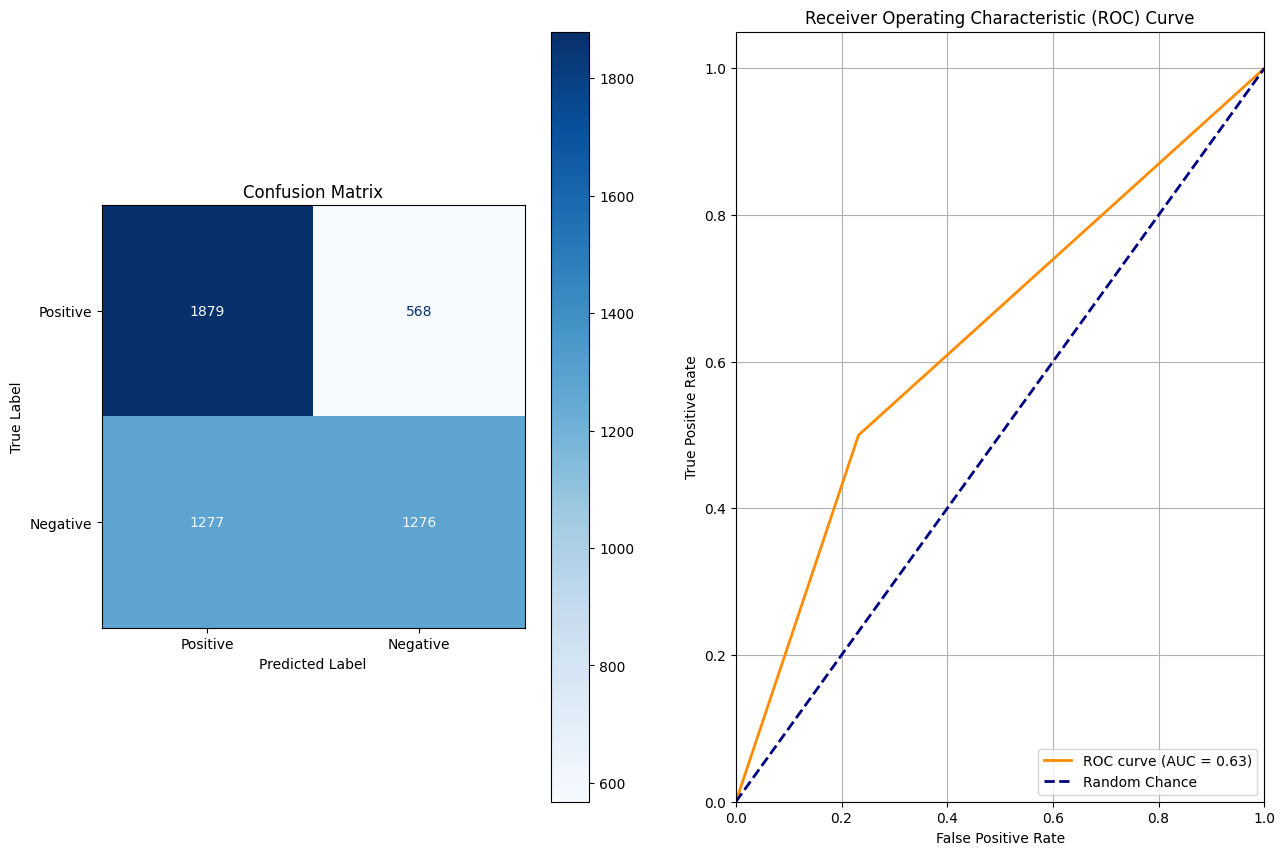

In [34]:
rnn_eval = ModelEvaluator(model_rnn)

rnn_eval.eval_model(novel_padded_sequences, novel_y, labels=["Positive", "Negative"])

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Number of Negative Predictions: 2825
Number of Positive Predictions: 2175
Percent Negative Predictions: 56.49999999999999
Percent Positive Predictions: 43.5

Accuracy: 75.84%

Recall: 0.8166862514688602

Precision: 0.7380530973451327

F1-Score: 0.78


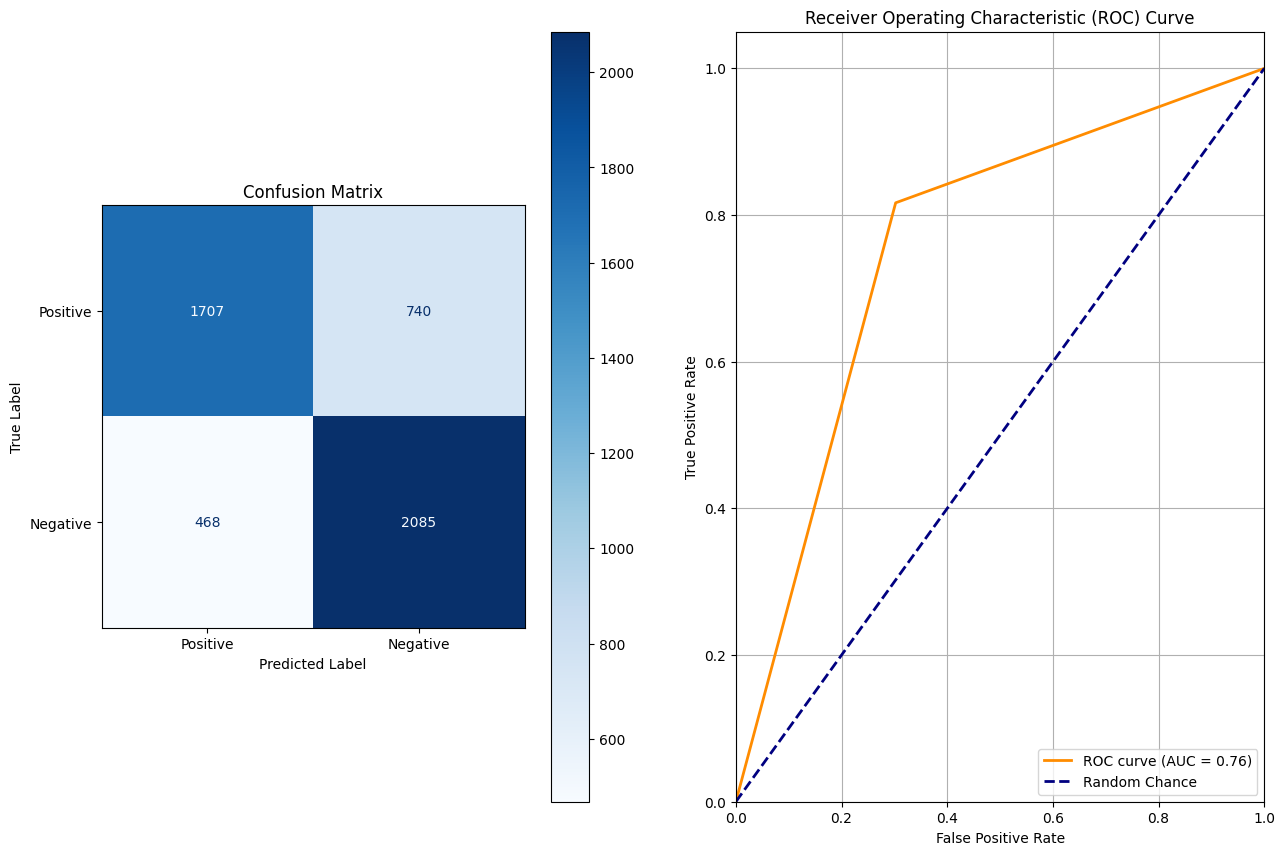

In [35]:
lstm_eval = ModelEvaluator(model_lstm)

lstm_eval.eval_model(novel_padded_sequences, novel_y, labels=["Positive", "Negative"])

Exercise:

1.	Reviewing your Precision and Recall, does your model tend to misclassify negative reviews as positive, or vice versa?
2.	Given the results, would you recommend this model for a production-level sentiment analysis tool? Why or why not?

#### Answers:

1. The original RNN model began to trend toward only positive label prediction, as seen by the 0.57 precision, which is specifically a result of positive class imbalance in the dataset, leading to more true positive predictions. Recall is lower, indicating the model is not adequately identifying all instances of positive labels, which is a result of misclassifying negative reviews as positive. The LSTM model did not suffer from either of these pitfalls.
2. The LSTM model would be far better for a production application, but it only reached an accuracy of 80%, which is where the LSTM models commonly plateau on this dataset. The RNN model is not acceptable for a production application, and, in fact, there was not a single instance of the model that performed well enough for production. A majority of the RNN models trained in section 4 learned to randomly guess, and the loss plateaued, indicating learning had ceased. The original model learned to commonly make positive predictions, which is not suitable for production. 